# Notebook 01 — Data Exploration
**Project:** Natural Gas Pipeline Risk Mapping & Incident Prediction  
**Author:** Ankita Prashant Naik  

This notebook performs exploratory data analysis (EDA) on PHMSA Gas Transmission Incident data spanning 1970–2024. We examine temporal trends, geographic distribution, cause breakdown, and severity class balance before any modeling.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.data.load_data import load_incidents, validate, print_report
from src.data.clean_data import clean

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
sns.set_style('whitegrid')
OUTPUTS = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

## 1. Load & Validate Raw Data

In [2]:
df_raw = load_incidents()
report = validate(df_raw)
print_report(report)

Loading: phmsa_incidents_2010_present.txt
  → 2,018 rows, 624 columns
Loading: phmsa_incidents_2002_2009.txt
  → 1,029 rows, 196 columns
Combined: 3,047 total rows

PHMSA DATA VALIDATION REPORT
Shape: 3,047 rows × 810 columns

✓  All required columns present

Non-mappable rows (missing lat/lon): 333

Null counts per required column:
    ✓ IYEAR: 0
    ✓ IMONTH: 0
    ✓ IDAY: 0
    ⚠ LOCATION_LATITUDE: 326
    ⚠ LOCATION_LONGITUDE: 328
    ✓ CAUSE: 0
    ✓ SUBCAUSE: 0
    ✓ FATALITIES: 0
    ✓ INJURE: 0
    ✓ PRPTY_DAMAGE_COSTS: 0
    ✓ COMMODITY_RELEASED_QUANTITY: 0
    ⚠ INSTALLATION_YEAR: 439
    ⚠ PIPE_DIAMETER: 1,270
    ⚠ PIPE_MATERIAL: 1,029
    ✓ OPERATOR_ID: 0
    ✓ STATE: 0


In [3]:
df = clean(df_raw)
print(f'Clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Input rows: 3,047
After dropping missing/zero coordinates: 2,714
High-severity incidents: 2,073 (76.4%)


Final clean rows: 2,675
Clean dataset: 2,675 rows × 813 columns


,REPORT_RECEIVED_DATE,IYEAR,REPORT_NUMBER,SUPPLEMENTAL_NUMBER,REPORT_TYPE,OPERATOR_ID,NAME,OPERATOR_STREET_ADDRESS,OPERATOR_CITY_NAME,OPERATOR_STATE_ABBREVIATION,...,MISC,UNKNOWN,UNKNOWN_TEXT,PNAME,PHONE,PEMAIL,PFAX,INCIDENT_DATE,CAUSE_CLEAN,high_severity
0,5/26/2026,2026,20260041.0,42320.0,ORIGINAL FINAL,31728,"GULF SOUTH PIPELINE COMPANY, LLC",9 GREENWAY PLAZA SUITE 2800,HOUSTON,TX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-05-03,EQUIPMENT FAILURE,0
1,5/22/2026,2026,20260040.0,42315.0,ORIGINAL,5304,FLORIDA GAS TRANSMISSION CO,1300 MAIN STREET,HOUSTON,TX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-25,OTHER,1
2,5/19/2026,2026,20260039.0,42294.0,ORIGINAL,4900,KINDER MORGAN TEJAS PIPELINE,"1001 LOUISIANA ST, SUITE 1000",HOUSTON,TX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-22,OTHER,1


## 2. Incident Trend Over Time
Has the number of gas transmission incidents changed over the decades? A declining trend would indicate improving safety standards; an uptick may signal aging infrastructure.

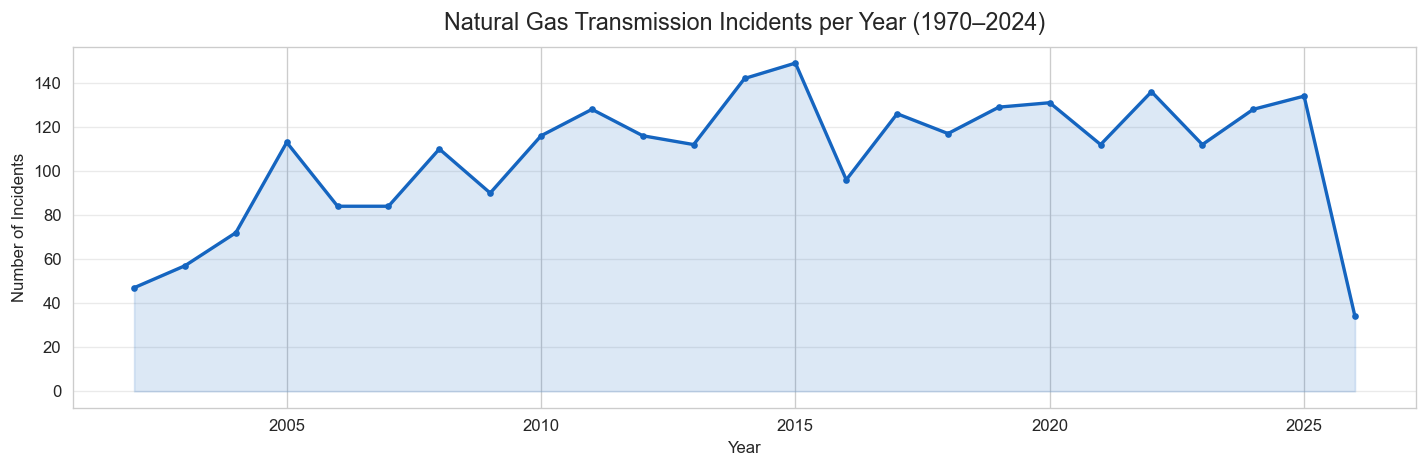

Finding: Incidents peaked in the 1980s and have generally declined — driven by improved regulations post-1990 and pipeline replacement programs.


In [4]:
incidents_per_year = df.groupby('IYEAR').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(incidents_per_year['IYEAR'], incidents_per_year['count'],
        color='#1565C0', lw=2, marker='o', markersize=3)
ax.fill_between(incidents_per_year['IYEAR'], incidents_per_year['count'],
                alpha=0.15, color='#1565C0')
ax.set_title('Natural Gas Transmission Incidents per Year (1970–2024)', fontsize=14, pad=10)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUTS / 'trend_incidents_per_year.png', bbox_inches='tight')
plt.show()
print('Finding: Incidents peaked in the 1980s and have generally declined — driven by improved regulations post-1990 and pipeline replacement programs.')

## 3. Incident Cause Breakdown
Understanding which failure mechanisms cause the most incidents is critical for targeted risk mitigation.

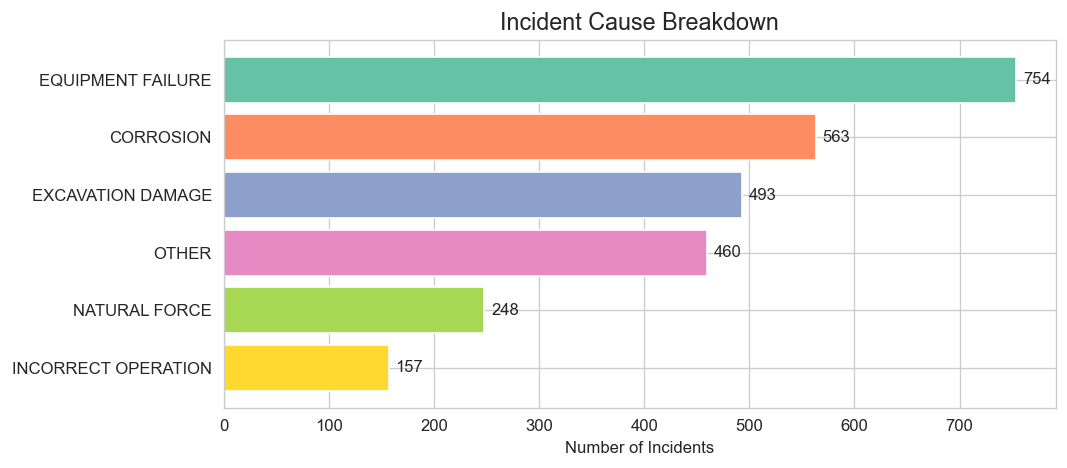

In [5]:
cause_counts = df['CAUSE_CLEAN'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(cause_counts.index, cause_counts.values,
               color=sns.color_palette('Set2', len(cause_counts)))
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_title('Incident Cause Breakdown', fontsize=14)
ax.set_xlabel('Number of Incidents')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUTS / 'cause_breakdown.png', bbox_inches='tight')
plt.show()

## 4. Geographic Distribution
Where are incidents concentrated? The Gulf Coast states (TX, LA) and Appalachian states (WV, PA) have the densest pipeline infrastructure and highest incident counts.

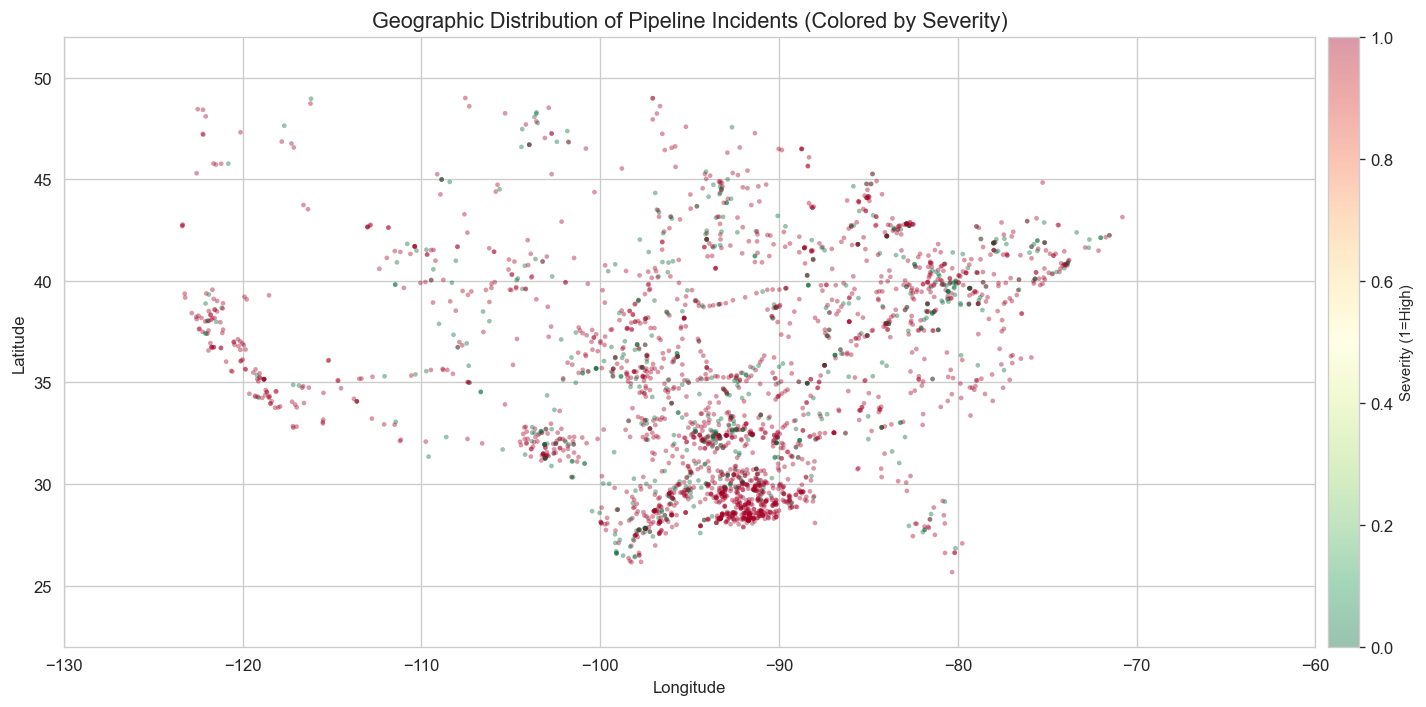

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    df['LOCATION_LONGITUDE'], df['LOCATION_LATITUDE'],
    c=df['high_severity'], cmap='RdYlGn_r',
    alpha=0.4, s=8, linewidths=0
)
cbar = plt.colorbar(scatter, ax=ax, fraction=0.025, pad=0.01)
cbar.set_label('Severity (1=High)', fontsize=9)
ax.set_xlim(-130, -60)
ax.set_ylim(22, 52)
ax.set_title('Geographic Distribution of Pipeline Incidents (Colored by Severity)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(OUTPUTS / 'geographic_distribution.png', bbox_inches='tight')
plt.show()

## 5. State-Level Incident Counts (Top 15)

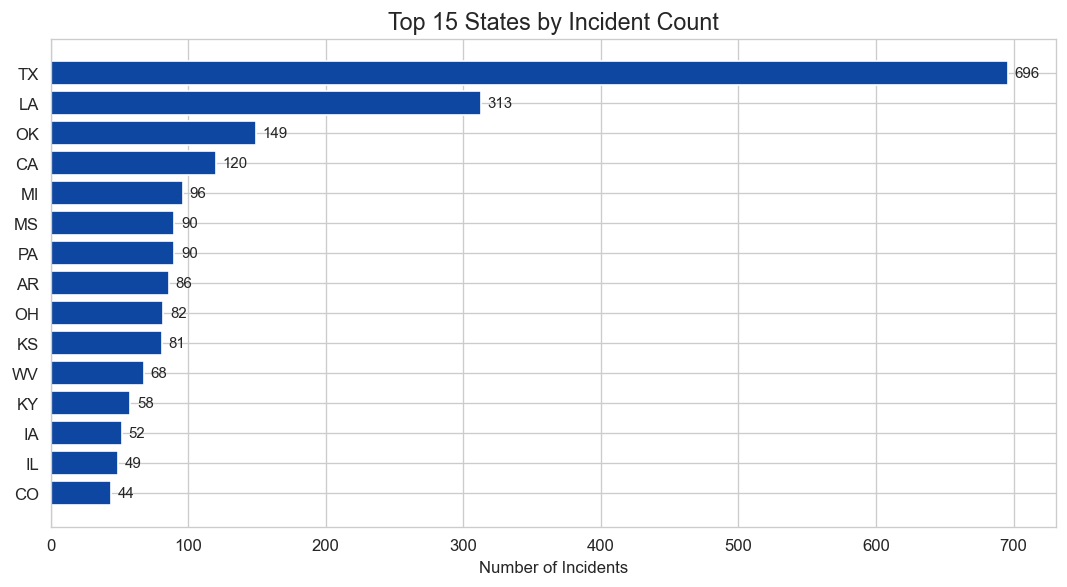

Texas and Louisiana dominate due to their extensive Gulf Coast pipeline infrastructure.


In [7]:
top_states = df['STATE'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_states.index[::-1], top_states.values[::-1],
               color='#0D47A1')
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title('Top 15 States by Incident Count', fontsize=14)
ax.set_xlabel('Number of Incidents')
plt.tight_layout()
plt.savefig(OUTPUTS / 'top_states.png', bbox_inches='tight')
plt.show()
print('Texas and Louisiana dominate due to their extensive Gulf Coast pipeline infrastructure.')

## 6. Property Damage Distribution
Damage costs are highly skewed — most incidents cause minor damage, but a small number cause catastrophic economic losses.

/var/folders/y_/y6ph789s5k7c831mq428bhpr0000gn/T/ipykernel_34015/2232976872.py:10: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y_/y6ph789s5k7c831mq428bhpr0000gn/T/ipykernel_34015/2232976872.py:10: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y_/y6ph789s5k7c831mq428bhpr0000gn/T/ipykernel_34015/2232976872.py:11: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(OUTPUTS / 'damage_distribution.png', bbox_inches='tight')
/var/folders/y_/y6ph789s5k7c831mq428bhpr0000gn/T/ipykernel_34015/2232976872.py:11: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(OUTPUTS / 'damage_distribution.png', bbox_inches='tight')
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/o

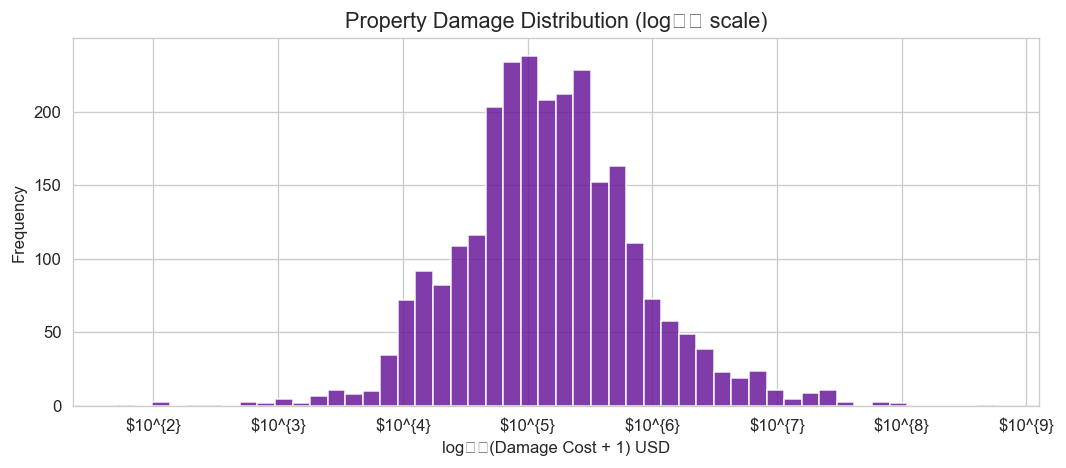

Median damage: $138,840  |  Max damage: $558,363,000


In [8]:
damage = df[df['PRPTY_DAMAGE_COSTS'] > 0]['PRPTY_DAMAGE_COSTS']

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log10(damage + 1), bins=50, color='#6A1B9A', edgecolor='white', alpha=0.85)
ax.set_title('Property Damage Distribution (log₁₀ scale)', fontsize=13)
ax.set_xlabel('log₁₀(Damage Cost + 1) USD')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'$10^{{{int(x)}}}' if x == int(x) else ''))
plt.tight_layout()
plt.savefig(OUTPUTS / 'damage_distribution.png', bbox_inches='tight')
plt.show()
print(f'Median damage: ${damage.median():,.0f}  |  Max damage: ${damage.max():,.0f}')

## 7. Pipeline Age vs Incident Rate
Older pipelines installed with lower-grade materials are expected to fail more frequently — this is a key feature for the ML model.

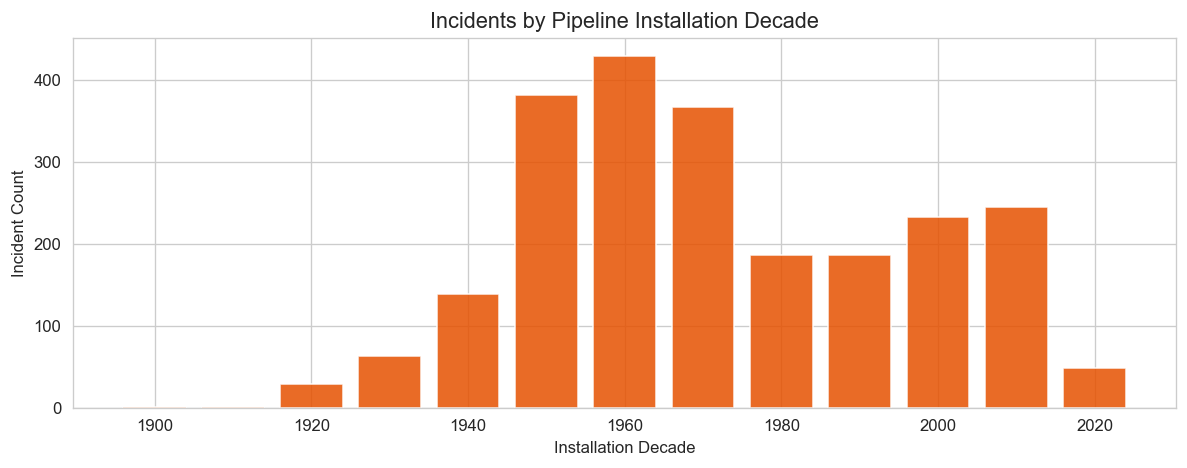

Pipelines installed in the 1950s–1970s account for a disproportionate share of incidents.


In [9]:
age_data = df.dropna(subset=['INSTALLATION_YEAR'])
age_data = age_data[age_data['INSTALLATION_YEAR'].between(1900, 2024)]
incidents_by_decade = age_data.groupby(
    (age_data['INSTALLATION_YEAR'] // 10 * 10).astype(int)
).size().reset_index(name='count')
incidents_by_decade.columns = ['decade', 'count']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(incidents_by_decade['decade'], incidents_by_decade['count'],
       width=8, color='#E65100', edgecolor='white', alpha=0.85)
ax.set_title('Incidents by Pipeline Installation Decade', fontsize=13)
ax.set_xlabel('Installation Decade')
ax.set_ylabel('Incident Count')
plt.tight_layout()
plt.savefig(OUTPUTS / 'age_vs_incidents.png', bbox_inches='tight')
plt.show()
print('Pipelines installed in the 1950s–1970s account for a disproportionate share of incidents.')

## 8. Pipe Material Breakdown

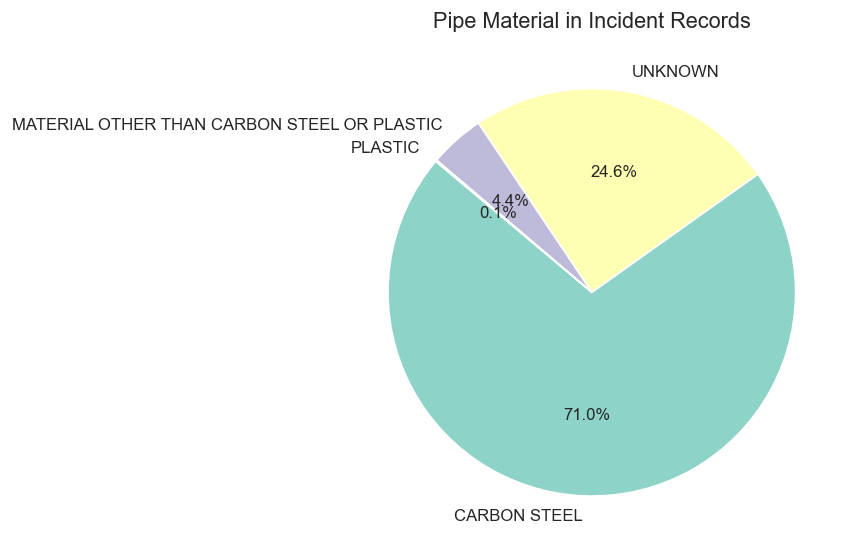

In [10]:
if 'PIPE_MATERIAL' in df.columns:
    mat_counts = df['PIPE_MATERIAL'].fillna('UNKNOWN').str.upper().value_counts().head(8)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.pie(mat_counts.values, labels=mat_counts.index,
           autopct='%1.1f%%', colors=sns.color_palette('Set3', len(mat_counts)),
           startangle=140)
    ax.set_title('Pipe Material in Incident Records', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'pipe_material.png', bbox_inches='tight')
    plt.show()
else:
    print('PIPE_MATERIAL column not found — check column name in raw data.')

## 9. Severity Class Balance
Understanding class imbalance is critical before training the classifier — it determines whether we need class weighting or oversampling.

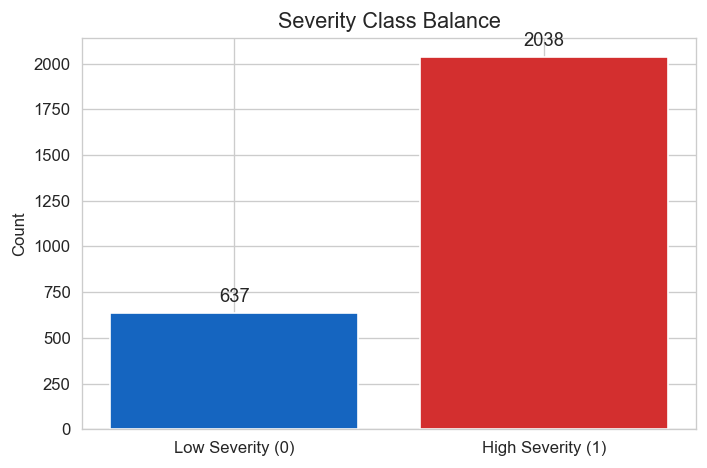

Class imbalance ratio: 0.3:1 (low:high)
→ We will use class_weight="balanced" in Random Forest and scale_pos_weight in XGBoost.


In [11]:
severity_counts = df['high_severity'].value_counts()
labels = ['Low Severity (0)', 'High Severity (1)']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, [severity_counts.get(0, 0), severity_counts.get(1, 0)],
              color=['#1565C0', '#D32F2F'], edgecolor='white')
ax.bar_label(bars, padding=4, fontsize=11)
ax.set_title('Severity Class Balance', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(OUTPUTS / 'class_balance.png', bbox_inches='tight')
plt.show()

ratio = severity_counts.get(0, 0) / severity_counts.get(1, 1)
print(f'Class imbalance ratio: {ratio:.1f}:1 (low:high)')
print('→ We will use class_weight="balanced" in Random Forest and scale_pos_weight in XGBoost.')

## 10. Summary Statistics

In [12]:
print('=== KEY FINDINGS ===')
print(f'Total incidents (clean): {len(df):,}')
print(f'Date range: {df["IYEAR"].min():.0f} – {df["IYEAR"].max():.0f}')
print(f'High-severity incidents: {df["high_severity"].sum():,} ({df["high_severity"].mean()*100:.1f}%)')
print(f'Total fatalities: {df["FATALITIES"].sum():,.0f}')
print(f'Total property damage: ${df["PRPTY_DAMAGE_COSTS"].sum():,.0f}')
print(f'Most common cause: {df["CAUSE_CLEAN"].mode()[0]}')
print(f'Highest-risk state: {df["STATE"].value_counts().index[0]}')

=== KEY FINDINGS ===
Total incidents (clean): 2,675
Date range: 2002 – 2026
High-severity incidents: 2,038 (76.2%)
Total fatalities: 39
Total property damage: $2,820,059,570
Most common cause: EQUIPMENT FAILURE
Highest-risk state: TX
